In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn import datasets
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import kagglehub
from scipy.io import arff
from imblearn.under_sampling import RandomUnderSampler

c:\Users\ejeme\Documents\python_repos\selective-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset : https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset

In [2]:
# Download latest version
path = kagglehub.dataset_download("yasserh/breast-cancer-dataset")

print("Path to dataset files:", path)

100%|██████████| 48.6k/48.6k [00:00<00:00, 714kB/s]

Extracting files...
Path to dataset files: C:\Users\ejeme\.cache\kagglehub\datasets\yasserh\breast-cancer-dataset\versions\1


In [24]:
df = pd.read_csv('C:/Users/ejeme/Documents/breast-cancer.csv')
df['diagnosis'].replace({'M':1, 'B':0}, inplace=True)
df.drop(['id'], axis=1, inplace=True)
df.head()

C:\Users\ejeme\AppData\Local\Temp\ipykernel_20160\102740474.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['diagnosis'].replace({'M':1, 'B':0}, inplace=True)
C:\Users\ejeme\AppData\Local\Temp\ipykernel_20160\102740474.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['diagnosis'].replac

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [22]:
print(df.shape)
print('Proportion of 1s:', np.round(df.diagnosis.sum()/df.shape[0],2))

(569, 32)
Proportion of 1s: 0.37


#### some preprocessing

In [25]:
features = df.drop(['diagnosis'], axis=1)
# missing values mean imputation
features = features.fillna(features.mean(numeric_only=True))
features.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [64]:
X = features.sample(n=2, axis=1, random_state=7)
Y = df.diagnosis

In [65]:
# split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.6, random_state=0, stratify=Y)

## <font color='yellow'> logistic regression

In [66]:
model = LogisticRegression(random_state=0, max_iter=1000)
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000, random_state=0)

In [67]:
# On test set after model selection
test_pred = model.predict(X_test)
print(classification_report(Y_test, test_pred))
print('Test Accuracy:', accuracy_score(Y_test, test_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       215
           1       0.85      0.83      0.84       127

    accuracy                           0.88       342
   macro avg       0.88      0.87      0.87       342
weighted avg       0.88      0.88      0.88       342

Test Accuracy: 0.8830409356725146


### Retrieving $\kappa_f$ confidence function

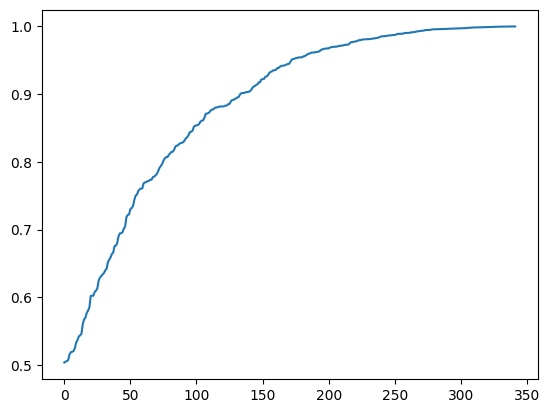

In [68]:
y_true = Y_test
y_pred = test_pred
kappa = model.predict_proba(X_test).max(axis=1)
plt.plot(sorted(kappa))

In [69]:
sgr_df = pd.DataFrame({'y_true': y_true,
              'y_pred': y_pred,
              'kappa': kappa}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
511,0,0,0.503727
347,0,1,0.504959
434,0,1,0.505754
90,0,0,0.507475
190,1,0,0.515635
...,...,...,...
202,1,1,0.999975
122,1,1,0.999993
82,1,1,0.999997
461,1,1,1.000000


In [74]:
pickle.dump(sgr_df, open('sgr_set_log_reg','wb'))

## <font color='yellow'> MLP

In [84]:
# Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32).view(-1, 1)

# Define  small MLP 
class SmallMLP(nn.Module):
    def __init__(self, input_dim):
        super(SmallMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Instantiate model, loss, optimizer
input_dim = X_train_tensor.shape[1]
model = SmallMLP(input_dim)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train the model
epochs = 60
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, Y_train_tensor)
    loss.backward()
    optimizer.step()

    # Optional: Evaluate on test set
    if epoch % 10 == 0 or epoch == epochs - 1:
        model.eval()
        with torch.no_grad():
            test_preds = model(X_test_tensor)
            test_preds_binary = (test_preds > 0.5).float()
            test_acc = (test_preds_binary == Y_test_tensor).float().mean().item()
            print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Test Acc: {test_acc*100:.2f}%")


Epoch 0 | Loss: 0.8435 | Test Acc: 24.85%
Epoch 10 | Loss: 0.7164 | Test Acc: 37.13%
Epoch 20 | Loss: 0.6203 | Test Acc: 71.05%
Epoch 30 | Loss: 0.5257 | Test Acc: 78.95%
Epoch 40 | Loss: 0.4378 | Test Acc: 83.04%
Epoch 50 | Loss: 0.3671 | Test Acc: 85.96%
Epoch 59 | Loss: 0.3208 | Test Acc: 85.96%


In [85]:
model.eval()
with torch.no_grad():
    test_probs = model(X_test_tensor)  # Shape: (num_samples, 1)
    test_preds = (test_probs > 0.5).float() 

In [86]:
sgr_df = pd.DataFrame({'y_true': Y_test,
                       'y_pred': test_preds.numpy().astype(int).flatten(),
                       'kappa': test_probs.numpy().flatten()}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
101,0,0,0.037309
568,0,0,0.040521
538,0,0,0.040570
314,0,0,0.045819
175,0,0,0.046120
...,...,...,...
122,1,1,0.997894
202,1,1,0.998522
82,1,1,0.998911
212,1,1,0.999159


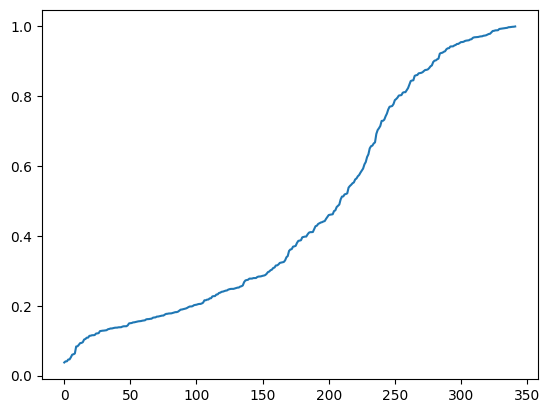

In [87]:
plt.plot(sorted(sgr_df.kappa))
plt.show()

In [89]:
pickle.dump(sgr_df, open('sgr_set_mlp', 'wb'))